# HF TDOA Analysis - Figure 9

This notebook creates Figure 9: Same Frequency Different Paths.

Shows layer height measurements at 7 MHz (40m band) over two different paths (WA5FRF-AB5YO 8.8 km and WA5FRF-N5DUP 317 km) compared with Austin ionosonde hmF2 data.

In [1]:
import datetime
import matplotlib.pyplot as plt
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Create Figure 9: Two Paths at 40m (7 MHz)

Figure 9 shows layer height measurements at the same frequency (7 MHz) over two different paths, demonstrating agreement between different path lengths and with the Austin ionosonde.

Figure saved to: fig_09.jpg


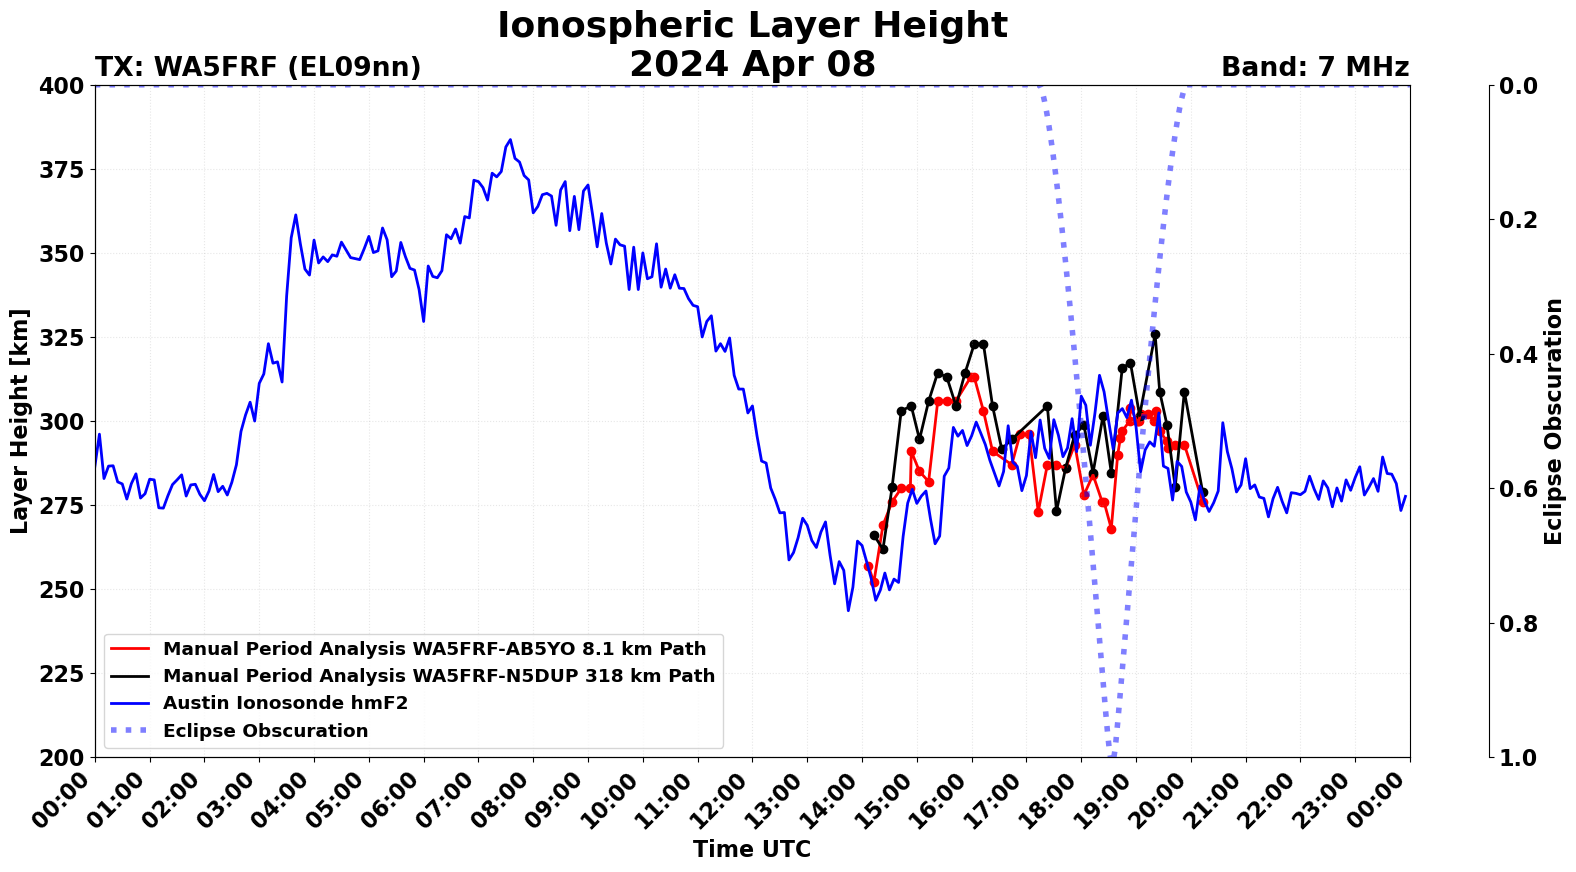

In [2]:
# Create PathInfo objects to get path information
path_info_ab5yo = tdoa.PathInfo('TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m')
path_info_n5dup = tdoa.PathInfo('TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m')

# Get solar coordinates for eclipse overlay
solar_lat, solar_lon = path_info_ab5yo.get_midpoint()

# Date for titles
date = datetime.datetime(2024, 4, 8)

# Create figure with single plot
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

# Set time limits for x-axis - full day
xlim = (datetime.datetime(2024, 4, 8), datetime.datetime(2024, 4, 9))
ylim = (200, 400)

# Plot WA5FRF-AB5YO path
ab5yo_range = path_info_ab5yo.get_range_km()
tdoa.overlay_tdoa_csv(
    ax,
    csv_path_period='../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_period_analysis.csv',
    label_period=f'Manual Period Analysis {path_info_ab5yo.tx_call}-{path_info_ab5yo.rx_call} {ab5yo_range:.1f} km Path',
    color_period='red',
    linestyle_period='solid'
)

# Plot WA5FRF-N5DUP path
n5dup_range = path_info_n5dup.get_range_km()
tdoa.overlay_tdoa_csv(
    ax,
    csv_path_period='../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_N5DUP_EM02ch-40m_manual_period_analysis.csv',
    label_period=f'Manual Period Analysis {path_info_n5dup.tx_call}-{path_info_n5dup.rx_call} {n5dup_range:.0f} km Path',
    color_period='black',
    linestyle_period='solid'
)

# Plot Austin ionosonde hmF2
tdoa.overlay_ionosonde(
    ax,
    csv_path='../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv',
    overlay_hmF2=True,
    overlay_hmE=False,
    label='Austin Ionosonde',
    hmF2_color='blue'
)

# Add solar elevation and eclipse overlay
from hf_tdoa import solarContext
solar_ts = solarContext.solarTimeseries(
    sTime=xlim[0],
    eTime=xlim[1],
    lat=solar_lat,
    lon=solar_lon
)
# Collect lines for legend
eclipse_line = solar_ts.overlayEclipse(ax)

# Format x-axis with datetime formatting
from matplotlib import dates as mdates
myFmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(myFmt)
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))  # Hourly ticks for full day

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_ylabel('Layer Height [km]')
ax.set_xlabel('Time UTC')
ax.grid(True, alpha=0.3)

# Create legend with all elements including eclipse
handles, labels = ax.get_legend_handles_labels()
if eclipse_line is not None:
    handles.append(eclipse_line)
    labels.append(eclipse_line.get_label())
ax.legend(handles=handles, labels=labels, loc='lower left', fontsize='small')

# Add custom title for multiple paths
# Center title with date and frequency info
ax.set_title('Ionospheric Layer Height\n2024 Apr 08', loc='center', fontsize=26)
# Left title with transmitter info from PathInfo
ax.set_title(f'TX: {path_info_ab5yo.tx_call} ({path_info_ab5yo.tx_grid})', loc='left')
# Right title with frequency from PathInfo
ax.set_title(f'Band: {path_info_ab5yo.band_str}', loc='right')

# Rotate x-axis labels
for tick_label in ax.get_xticklabels():
    tick_label.set_rotation(45)
    tick_label.set_horizontalalignment('right')

plt.tight_layout()

# Save figure
plt.savefig('fig_09.jpg', dpi=300, bbox_inches='tight', format='jpeg', pil_kwargs={'quality': 95})
print("Figure saved to: fig_09.jpg")

plt.show()